In [28]:
import pandas as pd
import numpy as np
import datetime as dt
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.linear_model import Ridge
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error, r2_score
import seaborn as sns
import matplotlib.pyplot as plt

In [29]:
#READING DATA
df = pd.read_csv('/content/online_retail_II.csv')
print(df.columns)
print(df.info())
duplicate_count = df.duplicated().sum()
print("Number of duplicate rows: ",duplicate_count)
print(df.head())

Index(['Invoice', 'StockCode', 'Description', 'Quantity', 'InvoiceDate',
       'Price', 'Customer ID', 'Country'],
      dtype='object')
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1067371 entries, 0 to 1067370
Data columns (total 8 columns):
 #   Column       Non-Null Count    Dtype  
---  ------       --------------    -----  
 0   Invoice      1067371 non-null  object 
 1   StockCode    1067371 non-null  object 
 2   Description  1062989 non-null  object 
 3   Quantity     1067371 non-null  int64  
 4   InvoiceDate  1067371 non-null  object 
 5   Price        1067371 non-null  float64
 6   Customer ID  824364 non-null   float64
 7   Country      1067371 non-null  object 
dtypes: float64(2), int64(1), object(5)
memory usage: 65.1+ MB
None
Number of duplicate rows:  34335
  Invoice StockCode                          Description  Quantity  \
0  489434     85048  15CM CHRISTMAS GLASS BALL 20 LIGHTS        12   
1  489434    79323P                   PINK CHERRY LIGHTS        12   

In [30]:
#Cleaning Data
df = df.drop_duplicates()     #removed duplicate rows
df = df[~df['Invoice'].astype(str).str.startswith('C')]  #removed cancelled orders
df = df.dropna(subset=['Customer ID'])    #removed rows with null customer ids
df = df[(df['Quantity'] > 0) & (df['Price'] > 0)] #removed rows with quantity quantity less than 0 price less than 0
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])
df['TotalSpend'] = df['Quantity'] * df['Price'] #total spend column = quantity x price
print("DF after cleaning: ")
print(df.info())


DF after cleaning: 
<class 'pandas.core.frame.DataFrame'>
Index: 779425 entries, 0 to 1067370
Data columns (total 9 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   Invoice      779425 non-null  object        
 1   StockCode    779425 non-null  object        
 2   Description  779425 non-null  object        
 3   Quantity     779425 non-null  int64         
 4   InvoiceDate  779425 non-null  datetime64[ns]
 5   Price        779425 non-null  float64       
 6   Customer ID  779425 non-null  float64       
 7   Country      779425 non-null  object        
 8   TotalSpend   779425 non-null  float64       
dtypes: datetime64[ns](1), float64(3), int64(1), object(4)
memory usage: 59.5+ MB
None


   Customer ID  Cluster                   Segment  Recency  Frequency  \
0      12346.0        0  Lost / Dormant Customers      326         12   
1      12347.0        0  Lost / Dormant Customers        2          8   
2      12348.0        0  Lost / Dormant Customers       75          5   
3      12349.0        0  Lost / Dormant Customers       19          4   
4      12350.0        1    Active Retail Shoppers      310          1   
5      12351.0        1    Active Retail Shoppers      375          1   
6      12352.0        0  Lost / Dormant Customers       36         10   
7      12353.0        0  Lost / Dormant Customers      204          2   
8      12354.0        0  Lost / Dormant Customers      232          1   
9      12355.0        0  Lost / Dormant Customers      214          2   

   Monetary  
0  77556.46  
1   4921.53  
2   2019.40  
3   4428.69  
4    334.40  
5    300.93  
6   2849.84  
7    406.76  
8   1079.40  
9    947.61  
Segment
Lost / Dormant Customers    3838
A

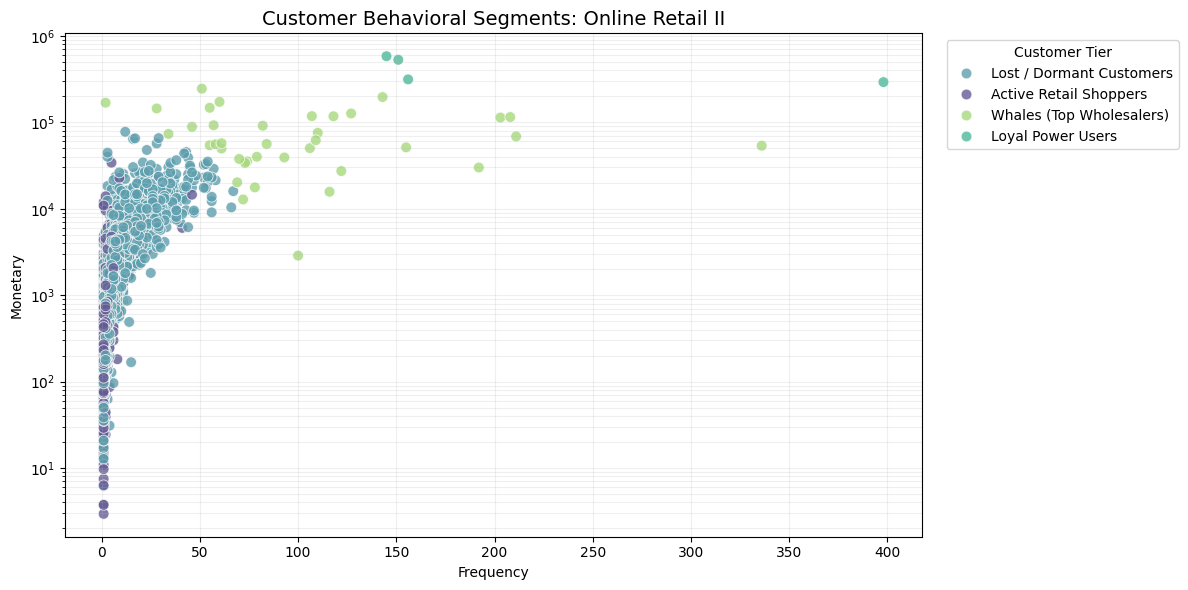

In [35]:
#RFM
snapshot_date = df['InvoiceDate'].max() + dt.timedelta(days=1)
rfm_df = df.groupby('Customer ID').agg({
    'InvoiceDate': lambda x: (snapshot_date - x.max()).days,
    'Invoice': 'nunique',
    'TotalSpend': 'sum'
}).reset_index()
rfm_df.rename(columns={
    'InvoiceDate': 'Recency',
    'Invoice': 'Frequency',
    'TotalSpend': 'Monetary'
}, inplace=True)
#K-Means
scaler = StandardScaler()
rfm_scaled = scaler.fit_transform(rfm_df[['Recency', 'Frequency', 'Monetary']])
kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
rfm_df['Cluster'] = kmeans.fit_predict(rfm_scaled)
rfm_dff=rfm_df.copy()
cluster_mapping = {
    1: 'Active Retail Shoppers',
    0: 'Lost / Dormant Customers',
    2: 'Loyal Power Users',
    3: 'Whales (Top Wholesalers)'
}
rfm_dff['Segment'] = rfm_dff['Cluster'].map(cluster_mapping)
display_cols = ['Customer ID', 'Cluster', 'Segment', 'Recency', 'Frequency', 'Monetary']
print(rfm_dff[display_cols].head(10))
print(rfm_dff['Segment'].value_counts())

fig, ax = plt.subplots(figsize=(12, 6))
custom_palette = {
    'Active Retail Shoppers': '#635b96',
    'Lost / Dormant Customers': '#5c9ead',
    'Loyal Power Users': '#4eb899',
    'Whales (Top Wholesalers)': '#a6d97c'
}
sns.scatterplot(
    data=rfm_dff,
    x='Frequency',
    y='Monetary',
    hue='Segment',
    palette=custom_palette,
    alpha=0.8,
    edgecolor='w',
    s=60,
    ax=ax
)
ax.set_yscale('log')
ax.set_title('Customer Behavioral Segments: Online Retail II', fontsize=14)
ax.set_xlabel('Frequency')
ax.set_ylabel('Monetary')
ax.legend(title='Customer Tier', bbox_to_anchor=(1.02, 1), loc='upper left')
ax.grid(True, which="both", ls="-", alpha=0.2)
plt.tight_layout()
plt.show()

In [36]:
#predictive
rfm_df['AOV'] = rfm_df['Monetary'] / (rfm_df['Frequency'] + 1e-5)
cluster_mapping = {
    0: 'Active_Shoppers',
    1: 'Lost_Dormant',
    2: 'Loyal_Power_Users',
    3: 'Whales'
}
rfm_df['Cluster'] = rfm_df['Cluster'].map(cluster_mapping)
rfm_df = pd.get_dummies(rfm_df, columns=['Cluster'], drop_first=True)
X = rfm_df.drop(columns=['Customer ID', 'Monetary'])
y_log = np.log1p(rfm_df['Monetary'])
X_train, X_test, y_train, y_test = train_test_split(X, y_log, test_size=0.2, random_state=42)
print(f"Training data shape: {X_train.shape}")
print(f"Testing data shape: {X_test.shape}\n")
models = {
    "Ridge Regression (Baseline)": Ridge(alpha=1.0),
    "Random Forest": RandomForestRegressor(n_estimators=100, random_state=42),
    "XGBoost (Advanced)": XGBRegressor(n_estimators=100, learning_rate=0.1, random_state=42)
}

results = []
print("************************************************************************")
print("Training models and metrics................................................")
for name, model in models.items():
    model.fit(X_train, y_train)
    log_predictions = model.predict(X_test)
    actual_predictions = np.expm1(log_predictions)
    actual_y_test = np.expm1(y_test)
    mae = mean_absolute_error(actual_y_test, actual_predictions)
    r2 = r2_score(actual_y_test, actual_predictions)
    results.append({
        "Model": name,
        "MAE (£)": round(mae, 2),
        "R-Squared": round(r2, 4)
    })
results_df = pd.DataFrame(results)
print("=== Preliminary Model Comparison ===")
print(results_df.to_string(index=False))
print("Starting Hyperparameter Tuning +++++++++++++++++++++++++++++++++++++++++++++++++++++++XGBoost...")
param_grid = {
    'max_depth': [3, 5, 7],
    'learning_rate': [0.01, 0.05, 0.1],
    'n_estimators': [100, 200]
}
xgb_base = XGBRegressor(random_state=42)
grid_search = GridSearchCV(
    estimator=xgb_base,
    param_grid=param_grid,
    cv=3,
    scoring='neg_mean_absolute_error',
    n_jobs=-1,
    verbose=1
)
grid_search.fit(X_train, y_train)
print(f"Best XGBoost Parameters: {grid_search.best_params_}")
best_xgb = grid_search.best_estimator_
optimized_log_preds = best_xgb.predict(X_test)
optimized_actual_preds = np.expm1(optimized_log_preds)
actual_y_test = np.expm1(y_test)
opt_mae = mean_absolute_error(actual_y_test, optimized_actual_preds)
opt_r2 = r2_score(actual_y_test, optimized_actual_preds)
print("++++++++++++++++++++++++++++ Optimized XGBoost Results+++++++++++++++++++++++++++++")
print(f"Optimized MAE (£): {opt_mae:.2f}")
print(f"Optimized R-Squared: {opt_r2:.4f}")

Training data shape: (4702, 6)
Testing data shape: (1176, 6)

************************************************************************
Training models and metrics................................................
=== Preliminary Model Comparison ===
                      Model  MAE (£)  R-Squared
Ridge Regression (Baseline)  2152.33     0.0917
              Random Forest   401.79     0.8620
         XGBoost (Advanced)   310.91     0.9292
Starting Hyperparameter Tuning +++++++++++++++++++++++++++++++++++++++++++++++++++++++XGBoost...
Fitting 3 folds for each of 18 candidates, totalling 54 fits
Best XGBoost Parameters: {'learning_rate': 0.1, 'max_depth': 7, 'n_estimators': 200}
++++++++++++++++++++++++++++ Optimized XGBoost Results+++++++++++++++++++++++++++++
Optimized MAE (£): 290.83
Optimized R-Squared: 0.9301


/tmp/ipykernel_36775/3171860847.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


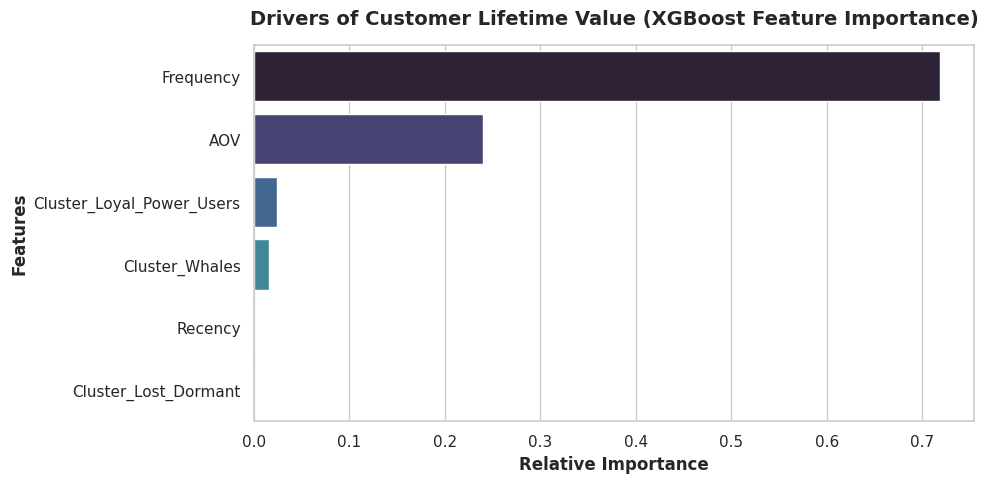

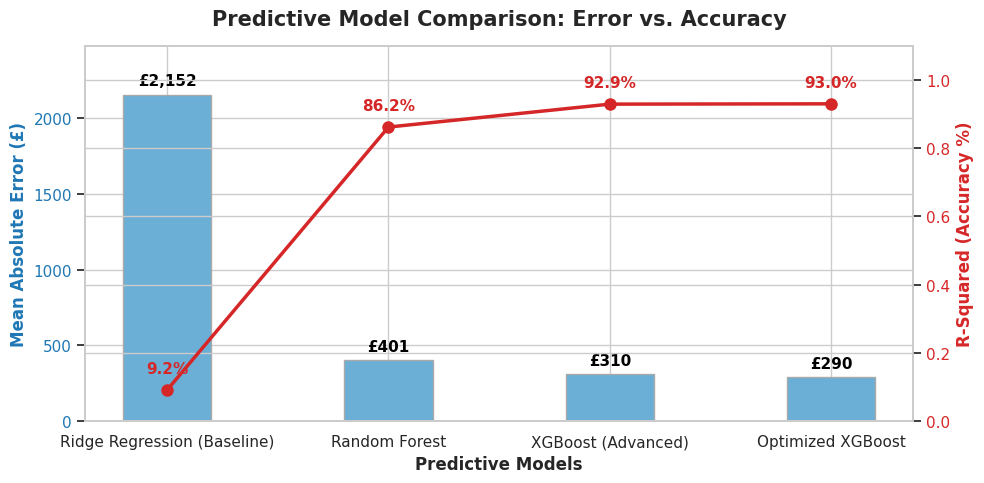

In [40]:
feature_importances = best_xgb.feature_importances_
features = X_train.columns

importance_df = pd.DataFrame({
    'Features': features,
    'Relative Importance': feature_importances
}).sort_values(by='Relative Importance', ascending=False)

plt.figure(figsize=(10, 5))
sns.set_theme(style="whitegrid")
sns.barplot(
    data=importance_df,
    x='Relative Importance',
    y='Features',
    palette='mako'
)
plt.title('Drivers of Customer Lifetime Value (XGBoost Feature Importance)', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Relative Importance', fontweight='bold')
plt.ylabel('Features', fontweight='bold')
plt.tight_layout()
plt.show()
models = results_df['Model'].tolist() + ['Optimized XGBoost']
mae_values = results_df['MAE (£)'].tolist() + [opt_mae]
r2_values = results_df['R-Squared'].tolist() + [opt_r2]

fig, ax1 = plt.subplots(figsize=(10, 5))
sns.set_theme(style="whitegrid")
bars = ax1.bar(models, mae_values, color='#6baed6', width=0.4, edgecolor='darkgray')
ax1.set_xlabel('Predictive Models', fontweight='bold', fontsize=12)
ax1.set_ylabel('Mean Absolute Error (£)', color='tab:blue', fontweight='bold', fontsize=12)
ax1.tick_params(axis='y', labelcolor='tab:blue')
ax1.set_ylim(0, max(mae_values) * 1.15)
for bar in bars:
    yval = bar.get_height()
    ax1.text(bar.get_x() + bar.get_width()/2, yval + (max(mae_values)*0.02),
             f'£{int(yval):,}', ha='center', va='bottom', fontweight='bold', color='black', fontsize=11)
ax2 = ax1.twinx()
color_line = '#d62728'
line = ax2.plot(models, r2_values, color=color_line, marker='o', markersize=8, linewidth=2.5)

ax2.set_ylabel('R-Squared (Accuracy %)', color=color_line, fontweight='bold', fontsize=12)
ax2.tick_params(axis='y', labelcolor=color_line)
ax2.set_ylim(0, 1.1)

for i, val in enumerate(r2_values):
    ax2.text(i, val + 0.04, f'{val*100:.1f}%', ha='center', va='bottom', fontweight='bold', color=color_line, fontsize=11)

plt.title('Predictive Model Comparison: Error vs. Accuracy', fontsize=15, fontweight='bold', pad=15)
plt.tight_layout()
plt.show()